# AeroFlow Visualisation

This notebook presents the key visual findings from the exploratory analysis, focusing on supplier performance, inventory risk, forecasting accuracy and quality performance.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

parts = pd.read_csv("../data/clean/parts_master_clean.csv")
purchase_orders = pd.read_csv("../data/clean/purchase_orders_clean.csv")
quality_incidents = pd.read_csv("../data/clean/quality_incidents_clean.csv")
supply_chain_history = pd.read_csv("../data/clean/supply_chain_history_clean.csv")

### Supplier OTIF Performance

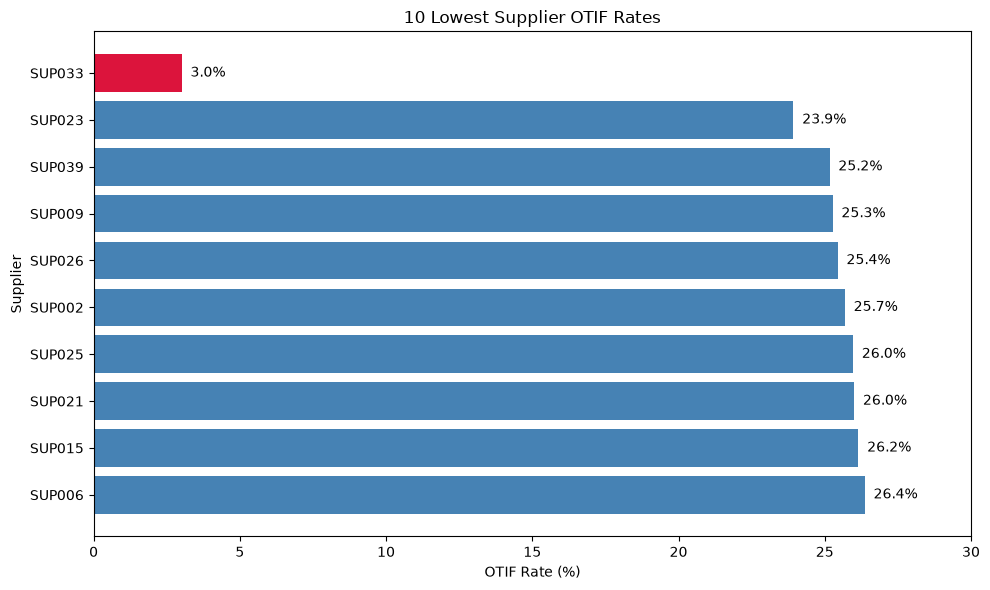

In [12]:
supplier_summary = (
    purchase_orders
    .groupby("supplier_id")
    .agg(
        order_count=("po_id", "count"),
        on_time_rate=("on_time_flag", "mean"),
        in_full_rate=("in_full_flag", "mean"),
        otif_rate=("otif_flag", "mean"),
        avg_delivery_delay_days=("delivery_variance_days", "mean")
    )
    .reset_index()
)

bottom_10_suppliers = (
    supplier_summary
    .sort_values("otif_rate")
    .head(10)
)

colors = [
    "crimson" if supplier == "SUP033" else "steelblue"
    for supplier in bottom_10_suppliers["supplier_id"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    bottom_10_suppliers["supplier_id"],
    bottom_10_suppliers["otif_rate"] * 100,
    color=colors
)

plt.xlabel("OTIF Rate (%)")
plt.ylabel("Supplier")
plt.title("10 Lowest Supplier OTIF Rates")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )
plt.xlim(0, 30)
plt.tight_layout()
plt.show()

SUP033 is a clear outlier, with an OTIF rate of only 3.0% compared with approximately 24–26% for the other weakest-performing suppliers. This reinforces the need for a targeted supplier recovery plan rather than treating poor supplier performance as a uniform issue across the supplier base.

### Stockouts Per Part Family

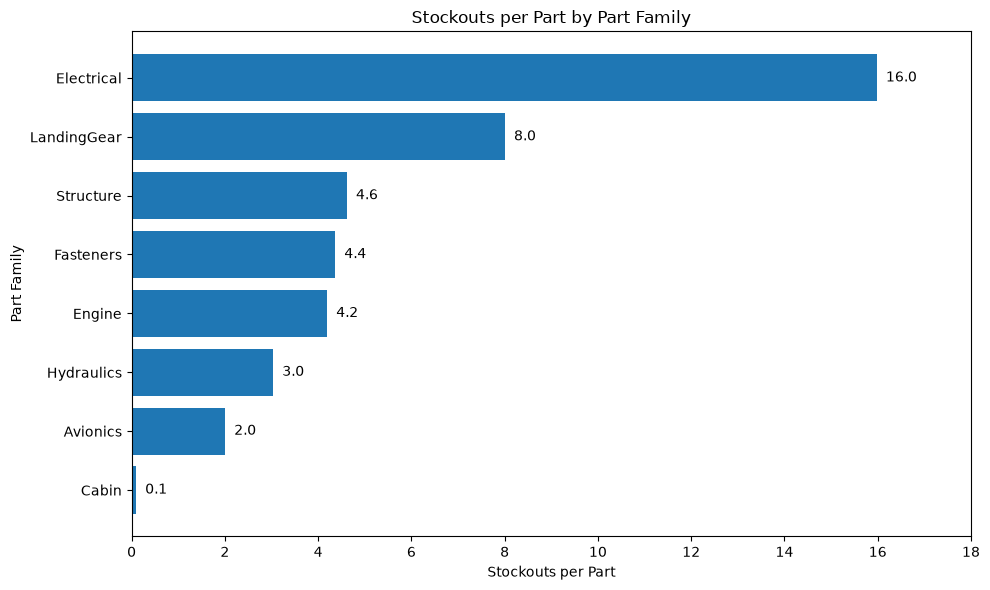

In [13]:
stockouts_by_family = (
    supply_chain_history
    .merge(
        parts[["part_id", "part_family"]],
        on="part_id",
        how="left"
    )
    .groupby("part_family")
    .agg(
        stockout_count=("stockout_flag", "sum")
    )
    .reset_index()
)

parts_per_family = (
    parts
    .groupby("part_family")
    .agg(
        part_count=("part_id", "count")
    )
    .reset_index()
)

stockouts_by_family = stockouts_by_family.merge(
    parts_per_family,
    on="part_family",
    how="left"
)

stockouts_by_family["stockouts_per_part"] = (
    stockouts_by_family["stockout_count"]
    / stockouts_by_family["part_count"]
)

stockouts_by_family = (
    stockouts_by_family
    .sort_values("stockouts_per_part", ascending=False)
    .reset_index(drop=True)
)

stockouts_by_family

plt.figure(figsize=(10, 6))

bars = plt.barh(
    stockouts_by_family["part_family"],
    stockouts_by_family["stockouts_per_part"]
)

plt.xlabel("Stockouts per Part")
plt.ylabel("Part Family")
plt.title("Stockouts per Part by Part Family")

plt.gca().invert_yaxis()
plt.xlim(0, 18)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Electrical parts show the highest stockout exposure at approximately 16 stockouts per part, around twice the rate of LandingGear and substantially above all other part families. This suggests inventory risk is concentrated within the Electrical portfolio rather than being evenly distributed across AeroFlow's parts base.

### Inventory Risk By Site

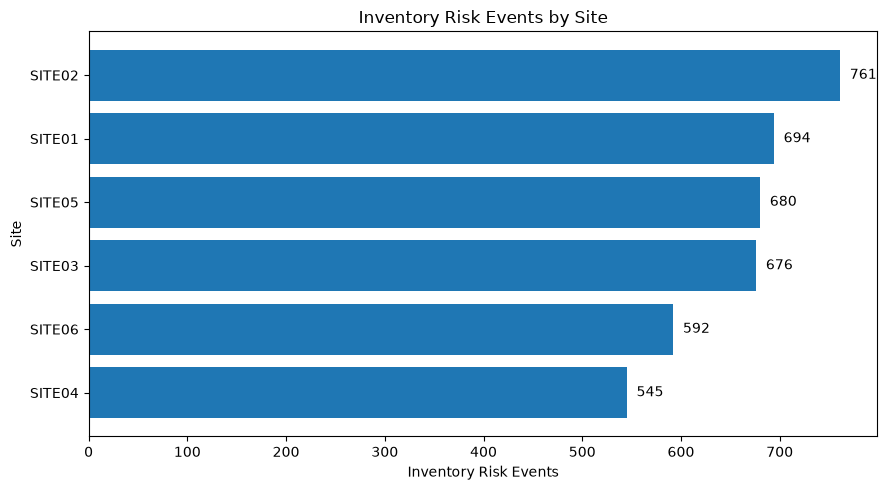

In [14]:
site_inventory_risk = (
    supply_chain_history
    .groupby("site_id")
    .agg(
        stockout_count=("stockout_flag", "sum"),
        backorder_count=("backorder_flag", "sum")
    )
    .reset_index()
)

site_inventory_risk["inventory_risk_events"] = (
    site_inventory_risk["stockout_count"]
    + site_inventory_risk["backorder_count"]
)

site_inventory_risk = (
    site_inventory_risk
    .sort_values("inventory_risk_events", ascending=False)
    .reset_index(drop=True)
)

site_inventory_risk

plt.figure(figsize=(9, 5))

bars = plt.barh(
    site_inventory_risk["site_id"],
    site_inventory_risk["inventory_risk_events"]
)

plt.xlabel("Inventory Risk Events")
plt.ylabel("Site")
plt.title("Inventory Risk Events by Site")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

SITE02 records the highest combined inventory-risk exposure, with the greatest total of stockout and backorder events. However, risk remains elevated across all sites, indicating that inventory availability is a network-wide issue rather than being isolated to one location.

### Forecast Accuracy by Part Family

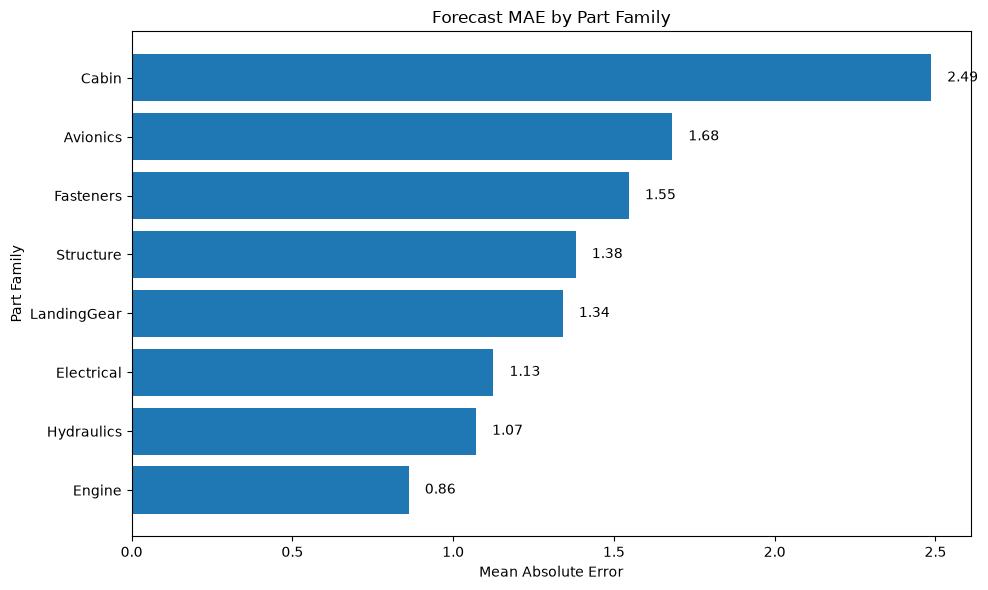

In [15]:
supply_chain_history["forecast_error"] = (
    supply_chain_history["forecast_qty"]
    - supply_chain_history["consumption_qty"]
)

supply_chain_history["absolute_forecast_error"] = (
    supply_chain_history["forecast_error"].abs()
)

forecast_by_family = (
    supply_chain_history
    .merge(
        parts[["part_id", "part_family"]],
        on="part_id",
        how="left"
    )
    .groupby("part_family")
    .agg(
        mae=("absolute_forecast_error", "mean")
    )
    .sort_values("mae", ascending=False)
    .reset_index()
)

forecast_by_family

plt.figure(figsize=(10, 6))

bars = plt.barh(
    forecast_by_family["part_family"],
    forecast_by_family["mae"]
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("Part Family")
plt.title("Forecast MAE by Part Family")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Cabin parts have the highest forecast error, with a mean absolute error of approximately 2.49 units. However, earlier inventory analysis showed that Cabin has very low stockout exposure, indicating that poor forecast accuracy is not currently the main driver of AeroFlow's inventory risk.

### Quality Burden by Criticality

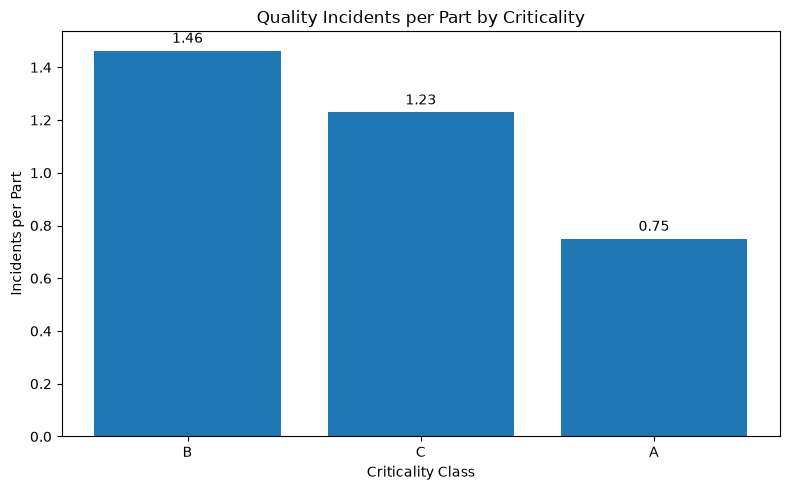

In [16]:
quality_by_criticality = (
    quality_incidents
    .merge(
        parts[["part_id", "criticality_class"]],
        on="part_id",
        how="left"
    )
    .groupby("criticality_class")
    .agg(
        incident_count=("incident_id", "count"),
        total_scrap_qty=("scrap_qty", "sum")
    )
    .reset_index()
)

parts_by_criticality = (
    parts
    .groupby("criticality_class")
    .agg(
        part_count=("part_id", "count")
    )
    .reset_index()
)

quality_criticality_rate = parts_by_criticality.merge(
    quality_by_criticality,
    on="criticality_class",
    how="left"
)

quality_criticality_rate["incidents_per_part"] = (
    quality_criticality_rate["incident_count"]
    / quality_criticality_rate["part_count"]
)

quality_criticality_rate["scrap_per_part"] = (
    quality_criticality_rate["total_scrap_qty"]
    / quality_criticality_rate["part_count"]
)

quality_criticality_rate = (
    quality_criticality_rate
    .sort_values("incidents_per_part", ascending=False)
    .reset_index(drop=True)
)

quality_criticality_rate

plt.figure(figsize=(8, 5))

bars = plt.bar(
    quality_criticality_rate["criticality_class"],
    quality_criticality_rate["incidents_per_part"]
)

plt.xlabel("Criticality Class")
plt.ylabel("Incidents per Part")
plt.title("Quality Incidents per Part by Criticality")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Class B parts have the highest normalised quality burden at approximately 1.46 incidents per part, followed by Class C at 1.23. Class A records the lowest incident rate, showing that raw incident totals alone would have overstated the quality burden within Class C.

## Key Visual Findings

The visual analysis highlights four main areas of operational risk across AeroFlow:

- **Supplier performance:** SUP033 is a significant outlier, with an OTIF rate of only 3.0%, substantially below the other weakest-performing suppliers.
- **Inventory availability:** Electrical parts experience the greatest stockout exposure at approximately 16 stockouts per part, while SITE02 records the highest combined stockout and backorder volume.
- **Forecasting:** Cabin parts have the highest forecast error, although this does not translate into high stockout exposure, suggesting forecasting accuracy is not the primary cause of AeroFlow's inventory availability issues.
- **Quality:** Class B parts carry the highest normalised quality burden, demonstrating the importance of adjusting raw incident counts for the size of each part group.

Overall, the visual evidence supports targeted interventions in supplier reliability, Electrical inventory management and Class B quality performance rather than broad changes across the entire supply chain.